In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rand = np.random.default_rng(seed = 50)

In [3]:
initial_positions = rand.random(20)

In [4]:
def velocity_from_one_point(point_position, neighbor_position,
        velocity_scalar = 100, minimum_distance = 1):
    
    distance_vector = neighbor_position - point_position
    if np.abs(distance_vector) >= minimum_distance:
        return 0
    if distance_vector == 0 :
        return 0
    direction = -np.sign(distance_vector)
    magnitude = np.min([0.2, np.abs(1 / distance_vector / velocity_scalar)])
    return direction * magnitude

In [5]:
def get_velocities(positions):
    velocities = []
    for position in positions:
        velocities.append(0)
        for neighbor in positions:
            velocities[-1] += velocity_from_one_point(position, neighbor)
    velocities = np.array(velocities)
    return velocities

In [6]:
position_snapshots = [initial_positions]
while True:
    velocities = get_velocities(position_snapshots[-1])
    if (velocities == np.zeros(len(velocities))).all():
        break
    position_snapshots.append(position_snapshots[-1] + velocities)

Text(0, 0.5, 'Points position')

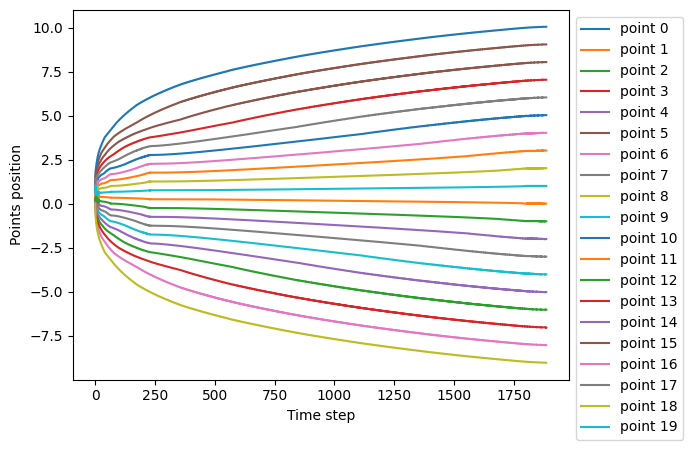

In [13]:
for index, trace in enumerate(np.transpose(np.array(position_snapshots))):
    plt.plot(trace, label = f"point {index}")
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
plt.xlabel("Time step")
plt.ylabel("Points position")